In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [41]:
def analyzer(max_depth):        #NOTE: max_depth - height of the tree 
    data =pd.read_csv('Social_Network_Ads.csv')
    X = data[['Age', 'EstimatedSalary']].values
    y = data['Purchased'].values

    clf = DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(X, y)

    a = np.arange(start=X[:, 0].min()-1, stop=X[:, 0].max()+1, step=0.1)
    b = np.arange(start=X[:, 1].min()-1, stop=X[:, 1].max()+1, step=100)

    XX,YY = np.meshgrid(a,b)

    input_array = np.array([XX.ravel(), YY.ravel()]).T
    
    labels = clf.predict(input_array)

    plt.contourf(XX, YY, labels.reshape(XX.shape), alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y)

In [42]:
data =pd.read_csv('Social_Network_Ads.csv')
data

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


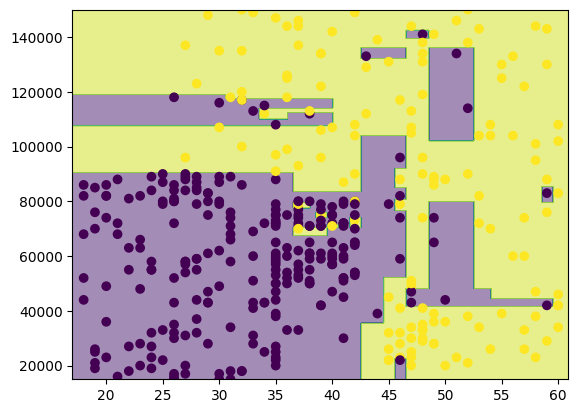

In [44]:
#NOTE: calling function : any passing different max_depth value to see the overfitting and underfgitting
analyzer(max_depth=None)
#NOTE: while passing NOne . It means the model is now free to split for n times . which will cause the model perform
# better in the training data but it will perform worse in testing data since we can see the outliters like the dots 
# where there is only 1, 2 purple dots while surrounded by yellow area though the model is labelling them as purple so 
# if new data comes with a datapoints near those outliers then because of those outliers the new yellow datapoints 
# will also be considered as purple. Whihch will ultimately affect model accuracy and make model worse . 

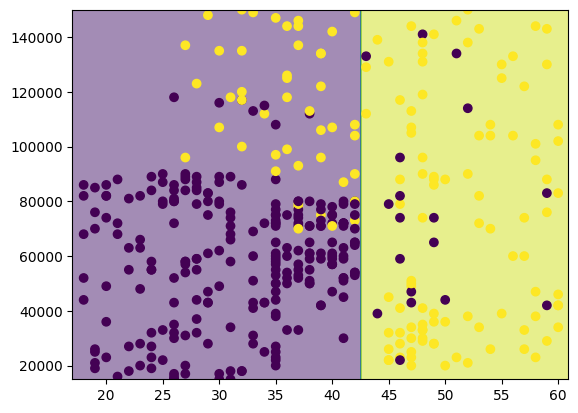

In [46]:
#NOTE : we can get optimal scatterplot manipulating max_depth hyperparameter to prevent the model from 
# overfitting and underfitting
analyzer(max_depth=1)       # NOTE: 1 means the model will only split once 

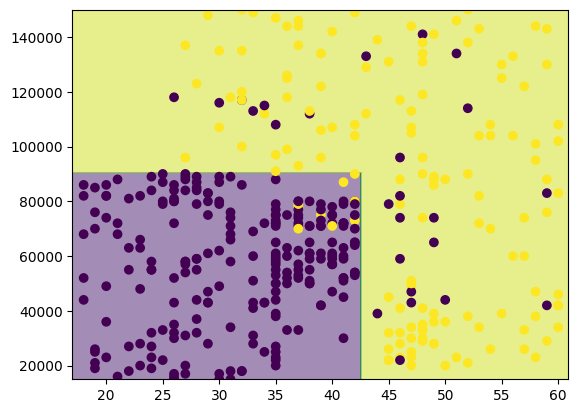

In [47]:
analyzer(max_depth=3)

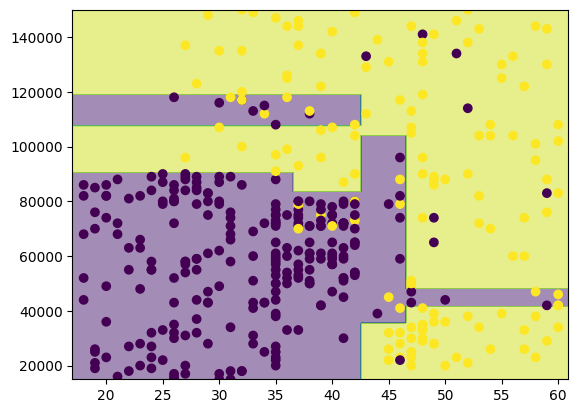

In [ ]:
analyzer(max_depth=4)  #NOTE: i think 4 will be best since we can see the dots which are separated wisely .